<font size="6.2">Summary</font>

The goal of this work is to **simulate a real-world, end-to-end machine learning application** in a local development environment by automating deployment with **Docker Compose**. This approach provides a fast, reliable, and reproducible setup for **local development and testing**.

The local environment includes:

* **Model training and experiment tracking** with [MLflow](https://mlflow.org/)
* **Model serving** via [FastAPI](https://fastapi.tiangolo.com/)
* **User interaction and visualization** using [Streamlit](https://streamlit.io/)

This setup allows teams to **validate integrations**, **debug end-to-end workflows**, and **ensure reproducibility** before deploying to production platforms such as **Kubernetes**.

**Workflow steps:**

1. Train an ML model and use the **MLflow UI** at [http://localhost:5555](http://localhost:5555) to track and manage experiments.
3. Open the **FastAPI documentation** at [http://localhost:8000/docs](http://localhost:8000/docs).
4. Launch the **Streamlit application** at [http://localhost:8501](http://localhost:8501).
5. Streamlit sends requests to FastAPI and displays model predictions.
6. All services are orchestrated together using `docker-compose up`.

By using **Docker Compose** for local deployment and testing, this project enables:

* **Consistent development and test environments** across machines
* **Portable and shareable ML applications**
* **Early validation of service integrations** before scaling to Kubernetes
* A workflow that mirrors how a **real AI/ML platform engineering team** operates

This project goes beyond simple containerization—it simulates a **production-grade ML architecture** within a controlled local environment. See the schematic illustration below:
<img src="deployment_schematic.gif" width="600" height="600">

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Deployment-Architecture-Overview" data-toc-modified-id="Deployment-Architecture-Overview-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Deployment Architecture Overview</a></span></li><li><span><a href="#Docker-Container-vs-Docker-Compose" data-toc-modified-id="Docker-Container-vs-Docker-Compose-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Docker Container vs Docker Compose</a></span></li><li><span><a href="#Model-Development" data-toc-modified-id="Model-Development-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Model Development</a></span><ul class="toc-item"><li><span><a href="#Packaged-Model-Development" data-toc-modified-id="Packaged-Model-Development-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Packaged Model Development</a></span></li></ul></li><li><span><a href="#MLflow" data-toc-modified-id="MLflow-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>MLflow</a></span><ul class="toc-item"><li><span><a href="#Packaged-MLflow" data-toc-modified-id="Packaged-MLflow-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Packaged MLflow</a></span></li></ul></li><li><span><a href="#Packaged-FastAPI-and-Streamlit" data-toc-modified-id="Packaged-FastAPI-and-Streamlit-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Packaged FastAPI and Streamlit</a></span><ul class="toc-item"><li><span><a href="#Building-Docker-Images-for-FastAPI-and-Streamlit" data-toc-modified-id="Building-Docker-Images-for-FastAPI-and-Streamlit-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Building Docker Images for FastAPI and Streamlit</a></span><ul class="toc-item"><li><span><a href="#FastAPI-Dockerfile" data-toc-modified-id="FastAPI-Dockerfile-5.1.1"><span class="toc-item-num">5.1.1&nbsp;&nbsp;</span>FastAPI Dockerfile</a></span></li><li><span><a href="#Streamlit-Dockerfile" data-toc-modified-id="Streamlit-Dockerfile-5.1.2"><span class="toc-item-num">5.1.2&nbsp;&nbsp;</span>Streamlit Dockerfile</a></span></li><li><span><a href="#Trigger-Docker-Compose" data-toc-modified-id="Trigger-Docker-Compose-5.1.3"><span class="toc-item-num">5.1.3&nbsp;&nbsp;</span>Trigger Docker Compose</a></span></li></ul></li><li><span><a href="#View-Created-Container-and-Images" data-toc-modified-id="View-Created-Container-and-Images-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>View Created Container and Images</a></span></li></ul></li></ul></div>

# Deployment Architecture Overview

The setup starts with **users interacting with a front-end application**, implemented using **Streamlit**. Streamlit provides a simple web-based interface where users can input data and request predictions.

Instead of loading and running the trained model directly from a pickle file in the UI, the model is **served through a backend API**. The trained model is wrapped using **FastAPI**, which exposes dedicated **prediction endpoints**. These endpoints handle incoming requests, load the trained model, and return prediction results in a structured format.

The **Streamlit application communicates with FastAPI** by sending HTTP requests to these endpoints and displaying the returned predictions to the user.

Behind the scenes, **model training and data processing** are tracked using **MLflow**. MLflow stores experiment metadata, parameters, metrics, and trained model artifacts, enabling reproducibility and experiment comparison. FastAPI can load the latest or selected model artifact registered in MLflow.

As illustrated in the figure above, this **deployment stack closely mirrors a production-grade architecture**, where:

* The **frontend** (Streamlit) is decoupled from the **backend** (FastAPI),
* The **model lifecycle** is managed and tracked with MLflow,
* All components are containerized and orchestrated together.

This design allows teams to **test end-to-end workflows**, **validate service integrations**, and **simulate real-world ML deployments** in a controlled local environment before moving to production platforms such as Kubernetes.


<img src="docker_compose_schematic.gif" width="800" height="800">

During model packaging and training, several processes take place in the **development environment**:

* We **automate model training pipelines** that use input data (e.g., feature datasets) to train the model and generate a pickle file.
* While this occurs, we **log experiments and metrics in MLflow**, which allows data scientists to track experiments, perform EDA, and manage model versions.

In this setup, we want **MLflow**, **FastAPI**, and **Streamlit** all running together — but they can also be executed **independently** when needed.

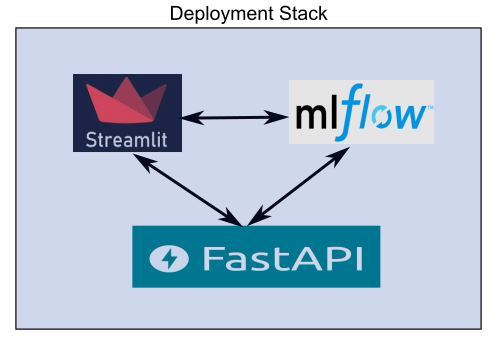

# Docker Container vs Docker Compose

**Docker Container** and **Docker Compose** are related, but they solve different problems.


* **Docker Container**

  A **Docker container** is a *running instance of an image*.
  
  * It packages an application **and all its dependencies** (code, runtime, libraries).
  * Containers are **lightweight**, isolated, and portable.
  * Run a single service (e.g., a Python API, a database, an ML model server).

Docker Container uses Dockerfile to build docker image:
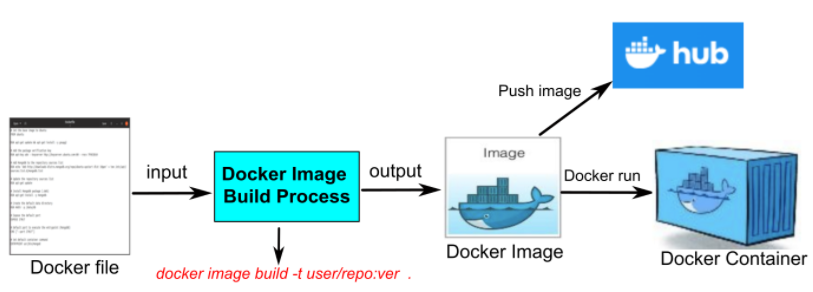

For more details about docker container, see this repository
[containerizing_ml_model_with_docker](https://github.com/MehdiRezvandehy/containerizing_ml_model_with_docker.git).

* **Docker Compose**

  **Docker Compose** is a **tool for defining and running multiple containers together**.
  
  * Uses a `*.yml` file to describe:
  
    * Multiple services (e.g., FastAPI, STreamlit ...)
    * Networks
    * Volumes
    * Environment variables
  
> **Docker containers run applications; Docker Compose runs and connects multiple containers as a single system.**
Docker Compose is needed to simplify the management of multi-container Docker applications. It allows to define and run multiple services in a single configuration file, making it easier to manage dependencies, environments, and scaling.
  
See schematic illustration below for Docker Compose. If there is no pre-built images (e.g. FastAPI, Streamlit ..), we need to create them ourselves using DockerFile as shown below:
  
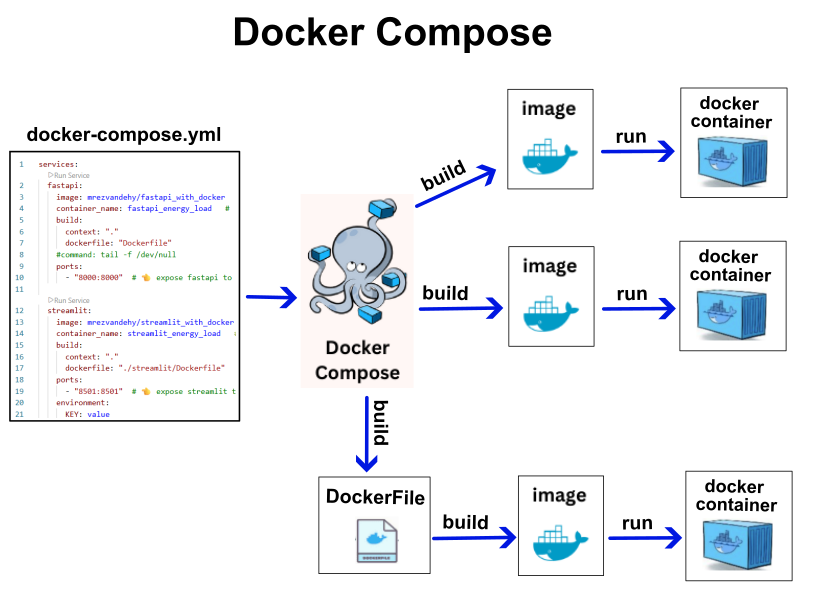  

# Model Development

First, we need to develop an ML model. A public data was used.
We can find different real datasets on the [UCI Machine Learning repository](https://archive.ics.uci.edu/) which are processed and cleaned before and ready to feed Machine Learning algorithms. Energy Efficiency data set https://archive.ics.uci.edu/ml/datasets/Energy+efficiency used for model development. Energy analysis are performed for 768 simulated building shapes with respect to 8 features including Wall Area, Overall Height, Glazing Area, Orientation.. to predict Heating Load and Cooling Load. The work has been published by Tsanas and Xifara 2012 on [Energy and Buildings Journal](https://www.sciencedirect.com/science/article/pii/S037877881200151X). The dataset can be used for both regression and classification. In this work, we  apply binary classification on Heating Load that is the amount of heating that a building needs in order to maintain the indoor temperature at established levels. 

In [1]:
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.metrics import confusion_matrix
import matplotlib
import pylab as plt
import numpy as np
import pickle
import yaml

In [2]:
df = pd.read_csv('./model/data/building_heating_load.csv',na_values=['NA','?',' '])
df[0:5]

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load,Binary Classes,Multi-Classes
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,Low Level,Level 2
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,Low Level,Level 2
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,Low Level,Level 2
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,Low Level,Level 2
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,Low Level,Level 2


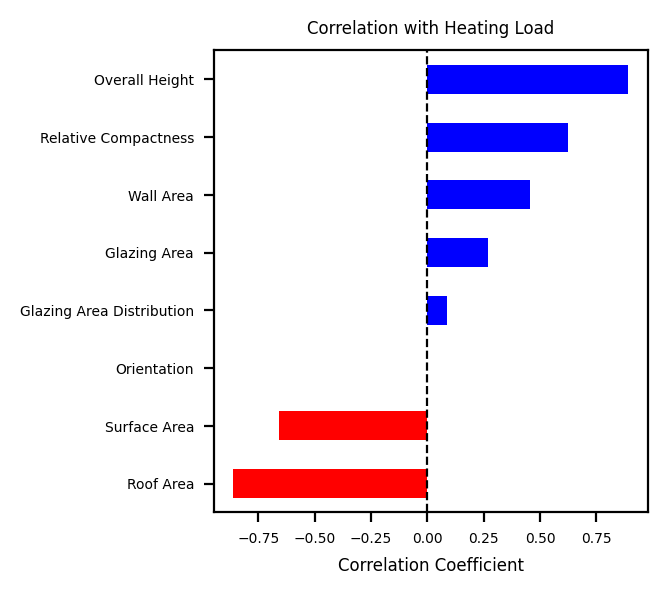

In [3]:
def corr_bar(df,title):
    """Plot correlation bar with the pair of atrribute with last column"""
    corr=df.drop(['Binary Classes', 'Multi-Classes'], axis=1).corr()
    Colms_sh=list(list(corr.columns))
    coefs=corr.values[:,-1][:-1]
    names=Colms_sh[:-1]
    r_ = pd.DataFrame( { 'coef': coefs, 'positive': coefs>=0  }, index = names )
    r_ = r_.sort_values(by=['coef'])
    r_['coef'].plot(kind='barh', color=r_['positive'].map({True: 'b', False: 'r'}))
    plt.xlabel('Correlation Coefficient',fontsize=6)
    plt.vlines(x=0,ymin=-0.5, ymax=10, color = 'k',linewidth=0.8,linestyle="dashed")
    plt.title(title)
    plt.show()
# 
import matplotlib
import pylab as plt

font = {'size'   : 5}
matplotlib.rc('font', **font)
ax1,fig = plt.subplots(figsize=(2.8, 3), dpi= 200, facecolor='w', edgecolor='k')

# Plot correlations of attributes with the last column
corr_bar(df,title='Correlation with Heating Load') 

In [4]:
np.random.seed(32) 
df = df.reindex(np.random.permutation(df.index))

In [5]:
df.columns

Index(['Relative Compactness', 'Surface Area', 'Wall Area', 'Roof Area',
       'Overall Height', 'Orientation', 'Glazing Area',
       'Glazing Area Distribution', 'Heating Load', 'Binary Classes',
       'Multi-Classes'],
      dtype='object')

In [6]:
df['Binary Classes']=df['Binary Classes'].replace({'Low Level': 0, 'High Level': 1})

C:\Users\mrezv\AppData\Local\Temp\ipykernel_29604\1836106052.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Binary Classes']=df['Binary Classes'].replace({'Low Level': 0, 'High Level': 1})


In [7]:
# Training and Test
spt = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in spt.split(df, df['Multi-Classes']):
    train_set_strat = df.loc[train_idx].reset_index(drop=True)
    test_set_strat  = df.loc[test_idx].reset_index(drop=True)  

In [8]:
train_set_strat.drop(['Heating Load','Multi-Classes'], axis=1, inplace=True)
test_set_strat.drop(['Heating Load','Multi-Classes'], axis=1, inplace=True)

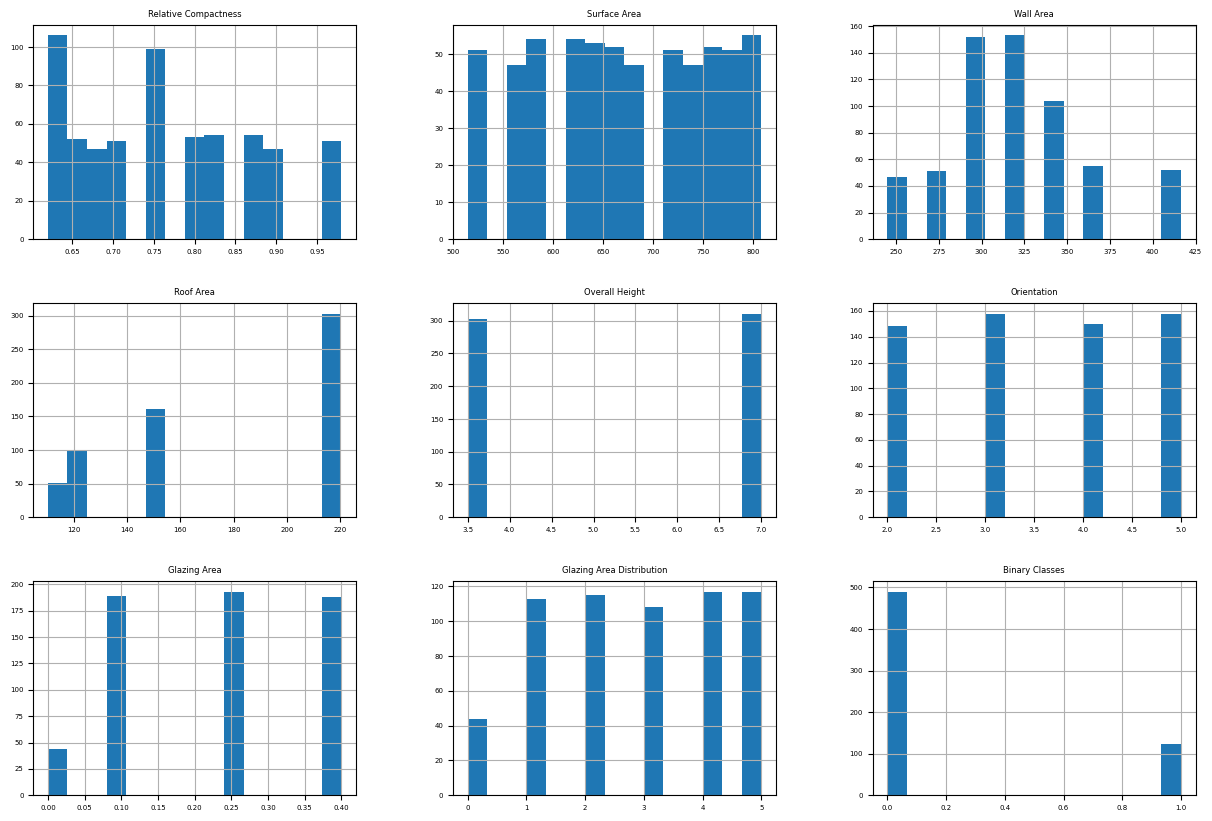

In [9]:
train_set_strat.hist(bins=15, layout=(3, 3), figsize=(15,10))
plt.show()

In [10]:
train_set_strat.describe()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Binary Classes
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.00000,614.000000,614.000000
mean,0.763632,672.114007,319.577362,176.268322,5.272801,3.517915,0.23184,2.801303,0.201954
std,0.105884,88.445470,43.515407,44.961674,1.751278,1.117343,0.13414,1.576623,0.401786
min,0.620000,514.500000,245.000000,110.250000,3.500000,2.000000,0.00000,0.000000,0.000000
25%,0.660000,612.500000,294.000000,147.000000,3.500000,3.000000,0.10000,1.000000,0.000000
50%,0.760000,661.500000,318.500000,147.000000,7.000000,4.000000,0.25000,3.000000,0.000000
75%,0.820000,759.500000,343.000000,220.500000,7.000000,5.000000,0.40000,4.000000,0.000000
max,0.980000,808.500000,416.500000,220.500000,7.000000,5.000000,0.40000,5.000000,1.000000


In [11]:
train_set_strat.columns

Index(['Relative Compactness', 'Surface Area', 'Wall Area', 'Roof Area',
       'Overall Height', 'Orientation', 'Glazing Area',
       'Glazing Area Distribution', 'Binary Classes'],
      dtype='object')

In [12]:
clmns = list(train_set_strat.drop(['Binary Classes'], axis=1).columns)
clmns

['Relative Compactness',
 'Surface Area',
 'Wall Area',
 'Roof Area',
 'Overall Height',
 'Orientation',
 'Glazing Area',
 'Glazing Area Distribution']

In [13]:
# Standardization training
scaler = StandardScaler()
x_train_std = scaler.fit_transform(train_set_strat.drop(['Binary Classes'], axis=1))
y_train = train_set_strat['Binary Classes']
#
x_test_std = scaler.transform(test_set_strat.drop(['Binary Classes'], axis=1))
y_test = test_set_strat['Binary Classes']

In [14]:
# Fine-tune RandomForest
rf = RandomForestClassifier(random_state=42)

# Define parameter distributions (can sample from ranges instead of fixed lists)
param_dist = {
    'n_estimators': [50, 100, 200, 300, 400],            # number of trees
    'max_depth': [10, 20, 40, 60, None],          # tree depth
    'min_samples_split': randint(2, 20),          # split threshold
    'min_samples_leaf': randint(1, 10),           # leaf node minimum
    'bootstrap': [True, False],                   # sampling with or without replacement
    'criterion': ['gini', 'entropy', 'log_loss']  # impurity metrics
}

# Randomized search setup
rf_search_cv = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,             # number of random combinations to try
    cv=5,
    scoring='accuracy',    # or 'f1', 'roc_auc', etc.
    n_jobs=-1,
    random_state=42,
    verbose=2
)

# Fit model
rf_search_cv.fit(x_train_std, y_train)

# Best parameters and score
print("Best Parameters:", rf_search_cv.best_params_)
print("Best Cross-Validation Score:", rf_search_cv.best_score_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'bootstrap': False, 'criterion': 'log_loss', 'max_depth': 40, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validation Score: 0.9625616420098627


In [15]:
def Conf_Matrix(predictor, x_train, y_train, perfect, sdt, axt=None):
    '''Plot confusion matrix'''
    ax1 = axt or plt.axes()
    y_train_pred = rf_search_cv.predict(x_train)
    if(perfect==1): y_train_pred=y_train
    conf_mx=confusion_matrix(y_train, y_train_pred)
    ii=0 
    if(len(conf_mx)<4):
        im =ax1.matshow(conf_mx, cmap='jet', interpolation='nearest')
        x=['Predicted\nNegative', 'Predicted\nPositive']; y=['Actual\nNegative', 'Actual\nPositive']
        for (i, j), z in np.ndenumerate(conf_mx):
            if(ii==0): al='TN= '
            if(ii==1): al='FP= '
            if(ii==2): al='FN= '
            if(ii==3): al='TP= '    
            ax1.text(j, i, al+'{:0.0f}'.format(z), ha='center', va='center', 
                     fontweight='bold',fontsize=10, color='w')
            ii=ii+1
        ax1.set_xticks(np.arange(len(x)))
        ax1.set_xticklabels(x,fontsize=9,y=0.97, rotation='horizontal')
        ax1.set_yticks(np.arange(len(y)))
        ax1.set_yticklabels(y,fontsize=9,x=0.035, rotation='horizontal')                
    else:
        if(sdt==1):
            row_sums = conf_mx.sum(axis=1, keepdims=True)
            norm_confmx = conf_mx / row_sums
        else:
            norm_confmx=conf_mx
            
        im =ax1.matshow(norm_confmx, cmap='jet', interpolation='nearest') 
        for (i, j), z in np.ndenumerate(norm_confmx): 
            if(sdt==1): ax1.text(j, i, '{:0.2f}'.format(z), ha='center', va='center', fontweight='bold')
            else: ax1.text(j, i, '{:0.0f}'.format(z), ha='center', va='center', fontweight='bold')  
    cbar =plt.colorbar(im,shrink=0.3,orientation='vertical')    

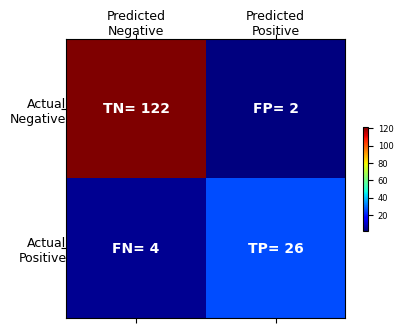

In [16]:
font = {'size'   : 6}
matplotlib.rc('font', **font)
fig, ax1 = plt.subplots(1, 1, figsize=(4.5, 4.5), dpi= 100, facecolor='w', edgecolor='k')

Conf_Matrix(rf_search_cv, x_test_std, y_test, perfect=0, sdt=0, axt=ax1)

## Packaged Model Development

The data processing and model training steps described above are packaged into a Python script so they can be executed as part of an automated pipeline. The script generates a `model_config.yaml` file containing the model’s performance metrics and the tuned hyperparameters. It also saves pickle files for the trained model, preprocessing steps, and data scalers. All of this logic is handled in [model_train.py](https://github.com/MehdiRezvandehy/end-to-end-ml-app-stack-with-docker-compose/blob/main/model/model_train.py)

These outputs serve as inputs to both **MLflow** (for experiment and model tracking) and **FastAPI** (for backend model inference).

The training script ([model_train.py](https://github.com/MehdiRezvandehy/end-to-end-ml-app-stack-with-docker-compose/blob/main/model/model_train.py)) is executed within the main pipeline [pipeline.py](https://github.com/MehdiRezvandehy/end-to-end-ml-app-stack-with-docker-compose/blob/main/pipeline.py), which loads the data, triggers model training, and writes the outputs to the specified directories. Below is the relevant section of [pipeline.py](https://github.com/MehdiRezvandehy/end-to-end-ml-app-stack-with-docker-compose/blob/main/pipeline.py):

```python
import subprocess
import sys

# Use the current environment's Python executable
python_executable = sys.executable
print(f"Current environment's Python executable: {python_executable}")

print('# ----------------------------------------------------------------------------------------------')
print('#                                1. Train the model                                             ')
print('# ----------------------------------------------------------------------------------------------')
subprocess.run([
    python_executable, "./model/model_train.py",
    "--config", "./model/configs/model_config.yaml",
    "--data", "./model/data/building_heating_load.csv",
    "--models-dir", "./model/pickles",
])
```

**Model Development Directory Structure**

```
pipeline.py
│
├── model/
│   ├── model_train.py
│   ├── data/
│   │   └── processed_data.csv
│   ├── configs/
│   │   └── model_config.yaml
│   ├── pickles/
│       └── scaler.pkl
```

#  MLflow

After the model development stage is complete, its outputs are fed into MLflow for experiment tracking. MLflow records model metrics, hyperparameters, artifacts, and performance plots. A script [run_mlflow.py](https://github.com/MehdiRezvandehy/end-to-end-ml-app-stack-with-docker-compose/blob/main/mlflow/run_mlflow.py) inside the `mlflow` folder reads the outputs from [model_train.py](https://github.com/MehdiRezvandehy/end-to-end-ml-app-stack-with-docker-compose/blob/main/model/model_train.py) and logs the results to MLflow. Once [model_train.py](https://github.com/MehdiRezvandehy/end-to-end-ml-app-stack-with-docker-compose/blob/main/model/model_train.py) and the MLflow script [run_mlflow.py](https://github.com/MehdiRezvandehy/end-to-end-ml-app-stack-with-docker-compose/blob/main/mlflow/run_mlflow.py) runs, the MLflow UI becomes available at http://localhost:5555.

The MLflow script ([run_mlflow.py](https://github.com/MehdiRezvandehy/end-to-end-ml-app-stack-with-docker-compose/blob/main/mlflow/run_mlflow.py)) is executed from the main pipeline ([pipeline.py](https://github.com/MehdiRezvandehy/end-to-end-ml-app-stack-with-docker-compose/blob/main/pipeline.py)), which loads the yaml file `model_config.yaml` generated during training. Below is the relevant section of [pipeline.py](https://github.com/MehdiRezvandehy/end-to-end-ml-app-stack-with-docker-compose/blob/main/pipeline.py):

```python
print('# ----------------------------------------------------------------------------------------------')
print('#                               2. Run MLflow                                                   ')
print('# ----------------------------------------------------------------------------------------------')
subprocess.run([
    python_executable, "mlflow/run_mlflow.py",
    "--config", "./model/configs/model_config.yaml",
    "--models-dir", "./model/pickles",
    "--mlflow-tracking-uri", "http://localhost:5555"
])
```

## Packaged MLflow

Running MLflow locally works for development, but for consistent collaboration across the team—using the same MLflow version, dependencies, and environment—a containerized setup is needed. This is where **Docker Compose** becomes useful.

MLflow provides a pre-built image, so we do not need to build it manually. A basic example of running MLflow using Docker is:

```bash
docker run -d --name mlflow -p 5555:5000 ghcr.io/mlflow/mlflow:latest mlflow server --host 0.0.0.0
```

This behavior can be captured in a `compose.yaml` file so it can be version-controlled and shared with the team. Everyone can then launch the exact same environment with a single command.

Docker Compose on Windows uses the `compose.yaml` naming convention. For MLflow, the file needs entries such as the service **name** (`mlflow_energy_load`), **image** (`ghcr.io/mlflow/mlflow:latest`), **port** mapping (`5555:5000`), **container_name**, and startup **command** (`mlflow server --host 0.0.0.0`). The resulting `compose.yaml` is:

```yaml
services:
  mlflow_energy_load:
    image: ghcr.io/mlflow/mlflow:latest
    container_name: mlflow_energy_load
    ports:
      - "5555:5000"
    command: mlflow server --host 0.0.0.0
```

This Docker Compose file is triggered from the main pipeline ([pipeline.py](https://github.com/MehdiRezvandehy/end-to-end-ml-app-stack-with-docker-compose/blob/main/pipeline.py)) using the following section:

```python
print('# ----------------------------------------------------------------------------------------------')
print('#                                3. Run MLflow Docker Compose                                   ')
print('# ----------------------------------------------------------------------------------------------')
print("Starting docker compose services...")
subprocess.run([
    "docker", "compose", "-f", "./mlflow/compose.yaml", "up", "-d"
], check=True)
```

**MLflow Directory Structure**

```
pipeline.py
│
├── mlflow/
│   ├── run_mlflow.py
│   ├── compose.yaml
```

Once started, MLflow runs on [http://localhost:5555](http://localhost:5555), and the entire team can view the tracking UI consistently across machines. Here is mlflow running on port 5555:

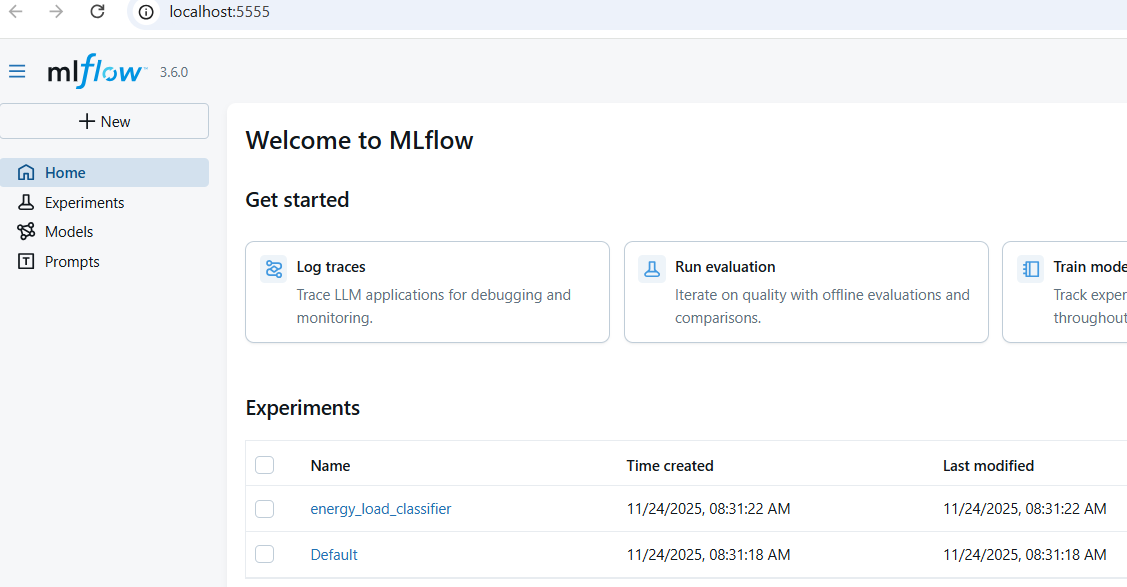

# Packaged FastAPI and Streamlit

We should follow a unified and centralized approach for both FastAPI and Streamlit, similar to how we use MLflow. In this setup, FastAPI loads the trained model (pickle file), receives input sent from the Streamlit UI, performs the prediction on the backend, and returns the result to Streamlit for display to the end-user.

This raises an important question: **Why not simply use Streamlit alone and skip FastAPI?**
Below are the key reasons why using FastAPI together with Streamlit is the better approach.


**1. Separation of concerns (clean architecture)**

* **Streamlit = UI**
* **FastAPI = backend logic + ML inference**

This makes the system easier to maintain, test, and scale.

If model or preprocessing changes, we can update only the FastAPI backend—
the UI does *not* need a redesign.

---

**2. Reliability & stability**

Streamlit is great for prototyping, but:

* It reloads the script whenever the user interacts.
* It reruns the Python file repeatedly.
* Large ML models may reload multiple times.

FastAPI runs the model **once at startup**, which is more stable.

---

**3. Performance**

FastAPI:

* Runs asynchronously
* Is very fast for API calls
* Handles multiple users at the same time

Streamlit is single-threaded and not optimized for serving fast inference to many users.

---

**4. Security**

APIs can implement:

* authentication
* rate limiting
* input validation
* logging

Streamlit doesn’t provide strong backend security features.

Companies require secure interfaces for ML services → FastAPI fits.

---

**5. Scalability & Production Deployment**

Companies need:

* Dockerized microservices
* Kubernetes support
* Load balancing
* Deployment pipelines

FastAPI can be packaged as a clean microservice.

Streamlit is mainly a **frontend visualization tool**, not a backend service.

---

**6. Multiple clients can use the same model**

With FastAPI, *one backend* can serve:

* Streamlit UI
* mobile apps
* internal dashboards
* monitoring services

This is extremely useful in enterprise.

If the model sits inside Streamlit, only the Streamlit app can use it.

---

**7. Streamlit is meant for UI, not backend computation**

Streamlit was built as:
✔ rapid prototyping
✔ interactive dashboards
✔ demos

Not as:
✘ inference engine
✘ heavy ML backend

FastAPI was specifically designed for backend APIs + ML serving.

## Building Docker Images for FastAPI and Streamlit

While we have Docker images for MLflow, we don’t yet have pre-built images for FastAPI and Streamlit, so we need to create them ourselves. Using **Docker Compose**, we can define and build both images in a structured way.

The general process is:

1. Build each image and optionally tag it for your Docker Hub registry (use Docker Hub username).
2. Specify the **build context** and **Dockerfile path** in the Docker Compose file to ensure the images are created correctly.
3. The context defines the folder used for building the image, and the Dockerfile contains the instructions for the image.

Section below shows Docker files for FastAPI and Streamlit. Each has its own code and requited packages to install: 



### FastAPI Dockerfile

This Dockerfile creates an image for the FastAPI backend:

```dockerfile
FROM python:3.11-slim

WORKDIR /app

# Copy only FastAPI app code
COPY fastapi/ /app/

# Copy the requirements file
COPY fastapi/requirements.txt /app/requirements.txt

# Install dependencies
RUN pip install -r requirements.txt

# Copy trained model pickle files
COPY ../model/pickles/*.pkl /app/model/pickles/

# Expose FastAPI port
EXPOSE 8000

# Run the FastAPI app
CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"]
```

**Explanation:**

* **FROM python:3.11-slim**: Uses a lightweight Python image.
* **WORKDIR /app**: Sets working directory in the container.
* **COPY**: Copies only necessary files to minimize image size.
* **RUN pip install -r requirements.txt**: Installs all dependencies.
* **EXPOSE 8000**: Makes FastAPI accessible on port 8000.
* **CMD**: Starts the FastAPI server using Uvicorn.


**FastAPI Directory Structure:**

```
pipeline.py
│
├── fastapi/
│   ├── main.py
│   ├── pydantic_objects.py
│   ├── run_prediction.py
│   ├── requirements.txt
├── Dockerfile
```
FastAPI needs these python codes: [main.py](https://github.com/MehdiRezvandehy/end-to-end-ml-app-stack-with-docker-compose/blob/main/fastapi/main.py), [pydantic_objects.py](https://github.com/MehdiRezvandehy/end-to-end-ml-app-stack-with-docker-compose/blob/main/fastapi/pydantic_objects.py), and [run_prediction.py](https://github.com/MehdiRezvandehy/end-to-end-ml-app-stack-with-docker-compose/blob/main/fastapi/run_prediction.py)

### Streamlit Dockerfile

This Dockerfile creates an image for the Streamlit frontend:

```dockerfile
FROM python:3.9-slim 

WORKDIR /app

# Copy only the Streamlit app code
COPY streamlit/ ./ 

# Install dependencies
RUN pip install -r requirements.txt

# Expose Streamlit port
EXPOSE 8501

# Run the Streamlit app
CMD ["streamlit", "run", "app.py", "--server.address=0.0.0.0"]
```

**Explanation:**

* **FROM python:3.9-slim**: Lightweight Python image for the frontend.
* **WORKDIR /app**: Container working directory.
* **COPY**: Copies only Streamlit app files.
* **RUN pip install -r requirements.txt**: Installs all app dependencies.
* **EXPOSE 8501**: Streamlit runs on port 8501.
* **CMD**: Starts the Streamlit app and listens on all interfaces.

**Streamlit Directory Structure:**

```
pipeline.py
│
├── streamlit/
│   ├── app.py
│   ├── requirements.txt
│   ├── Dockerfile
```

Python code for Streamlit is [app.py](https://github.com/MehdiRezvandehy/end-to-end-ml-app-stack-with-docker-compose/blob/main/streamlit/app.py).

---

* The FastAPI image serves as the backend, loading the ML model and handling prediction requests.
* The Streamlit image serves as the frontend, providing a UI and sending requests to FastAPI.
* Docker Compose allows us to define, build, and run both images together with proper port mapping.

### Trigger Docker Compose

Once we have separate Dockerfiles for FastAPI and Streamlit, the next step is to create a Docker Compose yaml file (`compose.yaml`) to orchestrate both services together. This file defines how the FastAPI backend and the Streamlit frontend run and interact.

```yaml
services:
  fastapi:
    image: mrezvandehy/fastapi_with_docker
    container_name: fastapi_energy_load
    build:
      context: "." 
      dockerfile: "Dockerfile"
    ports:
      - "8000:8000"  # Expose FastAPI on port 8000

  streamlit:
    image: mrezvandehy/streamlit_with_docker
    container_name: streamlit_energy_load
    build:
      context: "." 
      dockerfile: "./streamlit/Dockerfile"
    ports:
      - "8501:8501"  # Expose Streamlit on port 8501
    environment:
      KEY: value
```

**Explanation:**

* **fastapi service**: Builds and runs the FastAPI backend, exposing port 8000.
* **streamlit service**: Builds and runs the Streamlit frontend, exposing port 8501 and optionally using environment variables.
* **build context & dockerfile**: Specify the directory and Dockerfile for each service so Docker Compose knows how to build the images.

**Streamlit Directory Structure:**
```
pipeline.py
│
├── compose.yaml
```

This Docker Compose setup can be triggered programmatically from the main pipeline ([pipeline.py](https://github.com/MehdiRezvandehy/end-to-end-ml-app-stack-with-docker-compose/blob/main/pipeline.py)) using the following code:

```python
print('# ----------------------------------------------------------------------------------------------')
print('#                       4. Run Docker Compose for FastAPI & Streamlit                             ')
print('# ----------------------------------------------------------------------------------------------')
print("Starting Docker Compose services...")
subprocess.run([
    "docker", "compose", "-f", "compose.yaml", "up", "-d"
], check=True)
```

**Explanation:**

* This snippet runs `docker compose up -d` on the specified YAML file, starting both FastAPI and Streamlit containers in detached mode.
* Using the pipeline ensures the services are started automatically as part of your workflow.

## View Created Container and Images 

Here are created containers for FastAPI and Streamlit:

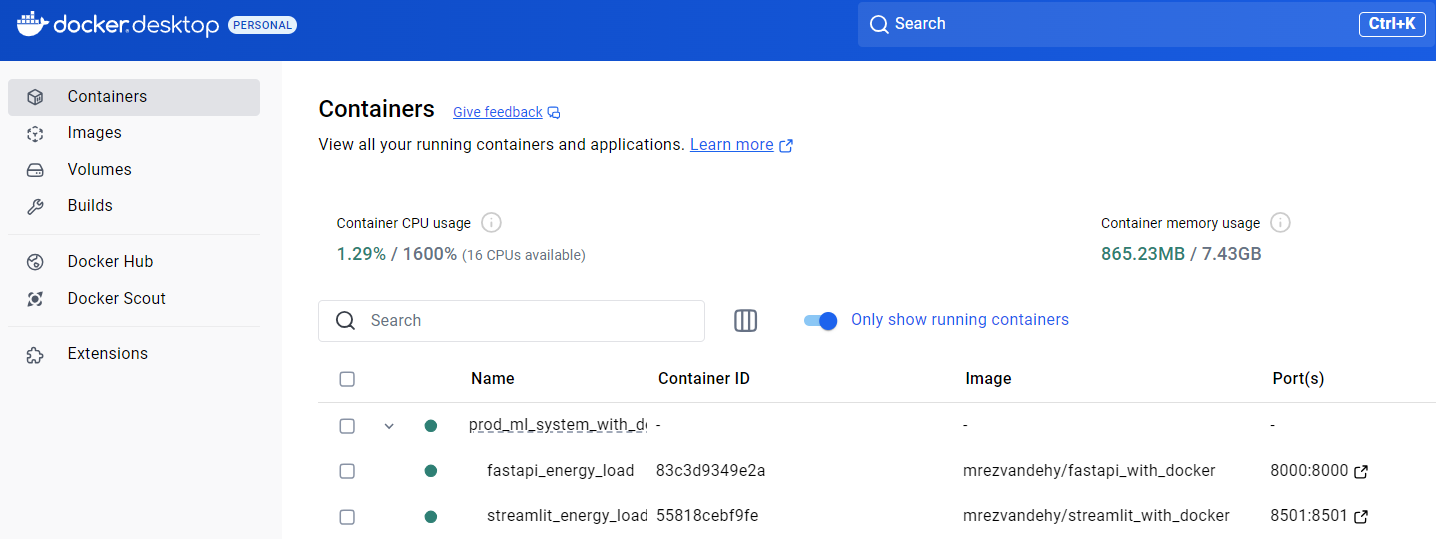

Here are images created for Streamlit and FastAPI:
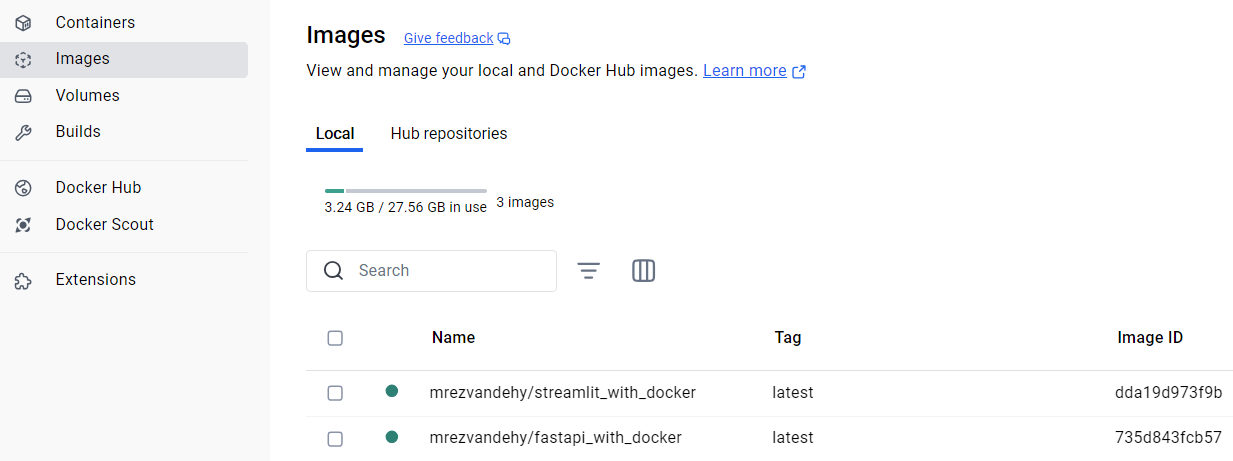

The FastAPI is available on port 8000: http://localhost:8000/docs#/

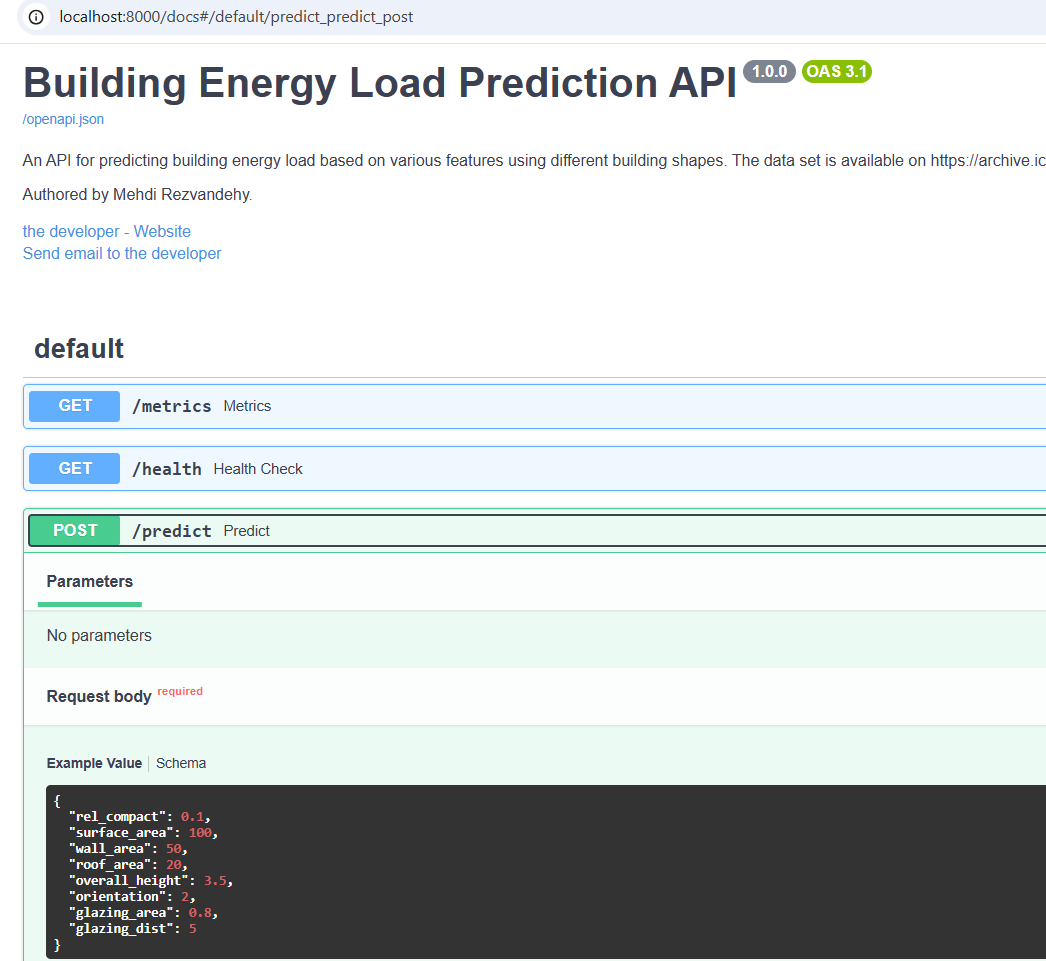


The Streamlit is available on port 8501: http://localhost:8501/

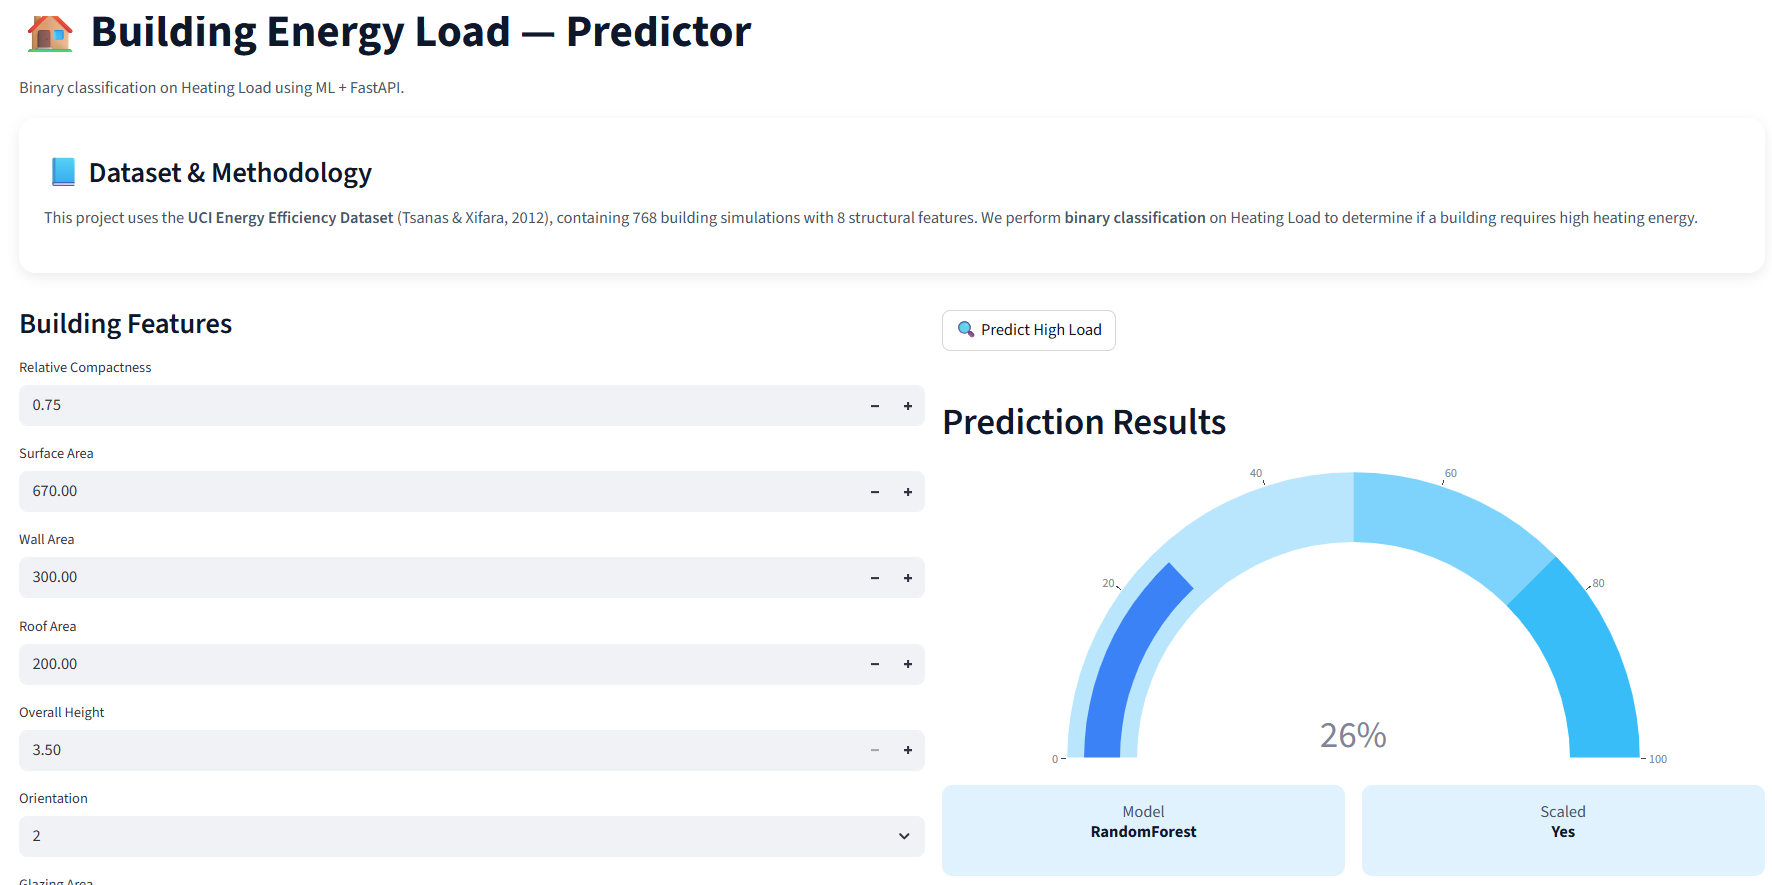

To update the code and run `pipeline.py` again, first we should delete the containers and image using the command below (for all images we created.
- `docker volume rm $(docker volume ls -q)`
- `docker rmi -f $(docker images -q)`